# 01 — Data and Portfolio Construction

**Multi-Asset Portfolio Risk and Stress-Testing Framework**

This notebook answers the first half of the project's business question: *how does
portfolio construction affect return, volatility and drawdown?* It documents the data,
then builds three portfolios from the same investable universe using three different
allocation rules, plus a 60/40 benchmark.

The rules are deliberately ordered by how much estimation they require. Equal weight
estimates nothing. Minimum variance estimates a covariance matrix. The volatility target
estimates a covariance matrix *and* commits to a risk level. If the added estimation does
not pay for itself, the equal-weight control will say so.

> **Disclaimer.** Every portfolio in this notebook is a *hypothetical research construct*
> built from publicly available price data. Nothing here represents a real client account,
> real assets under management, investment advice, or a forecast. Stress scenarios are
> analytical assumptions chosen to probe the portfolio, not predictions about markets.


## Setup

In [1]:
import sys, warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import display

from prisk.config import load_config
from prisk import data as dataio, portfolios as pf, metrics as mx
from prisk import risk as rk, stress as stx, backtest as bt, plots

plots.use_style()
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
pd.set_option("display.max_columns", 40)

cfg = load_config()
prices = dataio.load_panel(cfg)
returns = dataio.compute_returns(prices)
holdings = [t for t in cfg.holdings if t in returns.columns]
print(f"{len(prices):,} trading days | {prices.index[0].date()} to {prices.index[-1].date()} | {len(cfg.tickers)} instruments")


4,855 trading days | 2007-06-01 to 2026-09-17 | 15 instruments


## 1. The investable universe

Fifteen instruments spanning five asset-class sleeves. Eight individual equities give
single-name idiosyncratic risk (which an all-ETF portfolio would hide); the ETFs give
access to asset classes that cannot be held directly.

Two instruments do double duty. **SPY** is both a holding and the market proxy used for
beta. **BIL** is both the cash sleeve and the risk-free proxy used in the Sharpe ratio —
using an observable, daily, total-return series keeps the numerator and denominator of
every risk-adjusted metric internally consistent.

In [2]:
universe = cfg.universe.copy()
universe["first_price"] = prices.iloc[0].round(2)
universe["last_price"] = prices.iloc[-1].round(2)
display(universe[["name", "sleeve", "sector", "role", "first_price", "last_price"]])

,name,sleeve,sector,role,first_price,last_price
ticker,,,,,,
AAPL,Apple Inc.,equity,Information Technology,holding,3.5400,337.0000
MSFT,Microsoft Corporation,equity,Information Technology,holding,21.6500,497.7500
JNJ,Johnson & Johnson,equity,Health Care,holding,36.2000,270.2200
JPM,JPMorgan Chase & Co.,equity,Financials,holding,31.8100,349.3100
XOM,Exxon Mobil Corporation,equity,Energy,holding,43.0100,163.2700
PG,Procter & Gamble Company,equity,Consumer Staples,holding,36.5700,147.5500
CAT,Caterpillar Inc.,equity,Industrials,holding,48.1900,798.5700
NEE,NextEra Energy Inc.,equity,Utilities,holding,8.9200,81.2800
SPY,SPDR S&P 500 ETF Trust,equity_beta,Broad Equity,holding_and_market,107.9200,760.7100


## 2. Data provenance and cleaning

Everything a reader needs to reproduce or audit the sample:

| Item | Value |
|---|---|
| Source | Yahoo Finance daily bars |
| Price type | Split- and dividend-adjusted close |
| Start | 2007-06-01 (constrained by BIL's inception, 2007-05-30) |
| End | 2026-09-17 |
| Calendar | SPY's trading days |
| Missing data | Forward-fill up to 3 sessions; no back-filling; drop any still-incomplete row |
| Rebalancing | Quarterly |

Starting in June 2007 is a deliberate choice: it keeps the entire Global Financial Crisis
inside the sample. A framework whose worst observed episode is COVID has never been shown
a slow-moving credit crisis.

**Why no back-filling.** Forward-filling says "the price did not change", which is the
correct treatment of a non-trading day. Back-filling would use tomorrow's price to fill
today's gap — a look-ahead that leaks future information into every downstream
calculation.

In [3]:
quality = pd.read_csv(
    Path(cfg.path("data.processed_dir")) / "data_quality_report.csv", index_col=0
)
display(quality)

,first_obs,last_obs,n_raw,n_filled,pct_filled,n_final,n_zero_returns
ticker,,,,,,,
AAPL,2007-06-01,2026-09-17,4855,0,0.0000,4855,9
MSFT,2007-06-01,2026-09-17,4855,0,0.0000,4855,38
JNJ,2007-06-01,2026-09-17,4855,0,0.0000,4855,32
JPM,2007-06-01,2026-09-17,4855,0,0.0000,4855,21
XOM,2007-06-01,2026-09-17,4855,0,0.0000,4855,18
PG,2007-06-01,2026-09-17,4855,0,0.0000,4855,34
CAT,2007-06-01,2026-09-17,4855,0,0.0000,4855,7
NEE,2007-06-01,2026-09-17,4855,0,0.0000,4855,21
SPY,2007-06-01,2026-09-17,4855,0,0.0000,4855,13


The report is clean: no forward-filled observations and no dropped rows.

The one number worth reading closely is `n_zero_returns`. BIL shows ~1,800 zero-return
days out of 4,855. That is not a data error — a one-to-three-month T-bill ETF trading
around $91 frequently closes unchanged to the cent. It *is* a reminder that the cash
sleeve's measured volatility is downward-biased by price discreteness.

## 3. Asset-level behaviour

In [4]:
asset_stats = pd.DataFrame({
    "annualised_return": returns.apply(mx.annualised_return),
    "annualised_volatility": returns.apply(mx.annualised_volatility),
    "sharpe_ratio": returns.apply(
        lambda s: mx.sharpe_ratio(s, dataio.risk_free_daily(returns, cfg))),
    "max_drawdown": returns.apply(lambda s: mx.max_drawdown(s)["max_drawdown"]),
    "skewness": returns.apply(lambda s: mx.distribution_stats(s)["skewness"]),
    "excess_kurtosis": returns.apply(lambda s: mx.distribution_stats(s)["excess_kurtosis"]),
    "worst_day": returns.min(),
})
asset_stats["sleeve"] = pd.Series(cfg.sleeve_map())
display(asset_stats.sort_values("annualised_volatility", ascending=False))

,annualised_return,annualised_volatility,sharpe_ratio,max_drawdown,skewness,excess_kurtosis,worst_day,sleeve
JPM,0.1325,0.3731,0.4808,-0.6772,0.9051,18.3636,-0.2073,equity
CAT,0.1569,0.3270,0.5663,-0.7343,0.1103,4.6051,-0.1428,equity
AAPL,0.2668,0.3126,0.8677,-0.6087,-0.0677,6.4787,-0.1792,equity
VNQ,0.0520,0.2959,0.2726,-0.7056,0.0169,16.7078,-0.1951,real_estate
MSFT,0.1768,0.2833,0.6661,-0.5794,0.3961,9.6940,-0.1474,equity
XOM,0.0717,0.2715,0.3393,-0.6240,0.2022,9.6610,-0.1395,equity
NEE,0.1215,0.2471,0.5310,-0.4781,0.2257,10.6074,-0.1342,equity
SPY,0.1067,0.1970,0.5414,-0.5519,0.0072,14.4511,-0.1094,equity_beta
DBC,0.0241,0.1933,0.1487,-0.7636,-0.4058,3.1801,-0.0794,commodity
PG,0.0751,0.1863,0.4070,-0.3901,0.0755,9.4391,-0.0874,equity


Two things stand out.

**Every asset has large positive excess kurtosis.** Under a normal distribution this
number would be zero. It is not close to zero for anything here, including the bond ETF.
That single fact is why this project implements three VaR methods rather than one: a
model that assumes normality is assuming away the most important feature of the data.

**Volatility ranks very differently from drawdown.** An asset's standard deviation tells
you about a typical day; its maximum drawdown tells you about the worst path it ever
took. Portfolio construction has to answer to both.

## 4. Correlation structure

Correlation is what makes diversification work, and it is also the least stable input in
the whole framework. The matrix below is the full-sample average — a number that no
investor ever actually experiences, because correlations move.

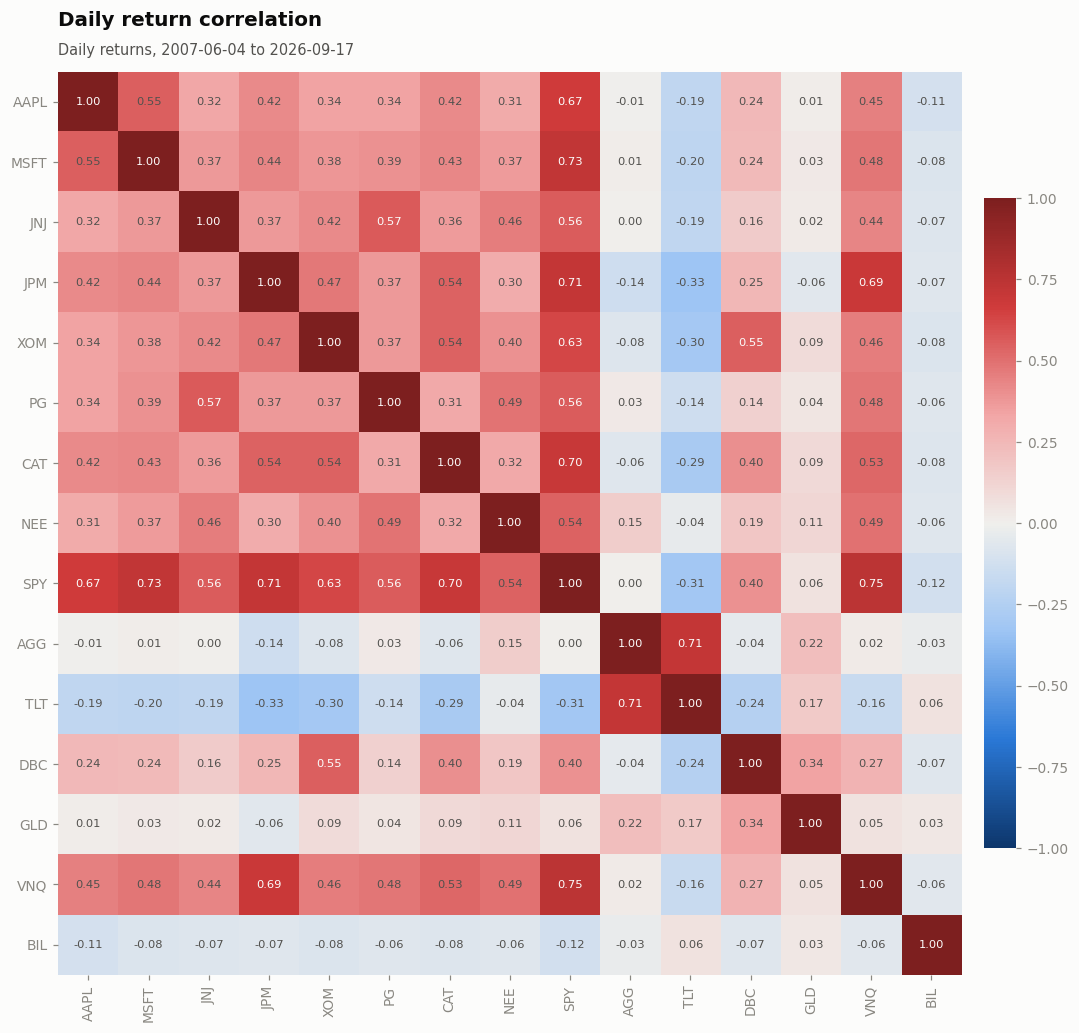

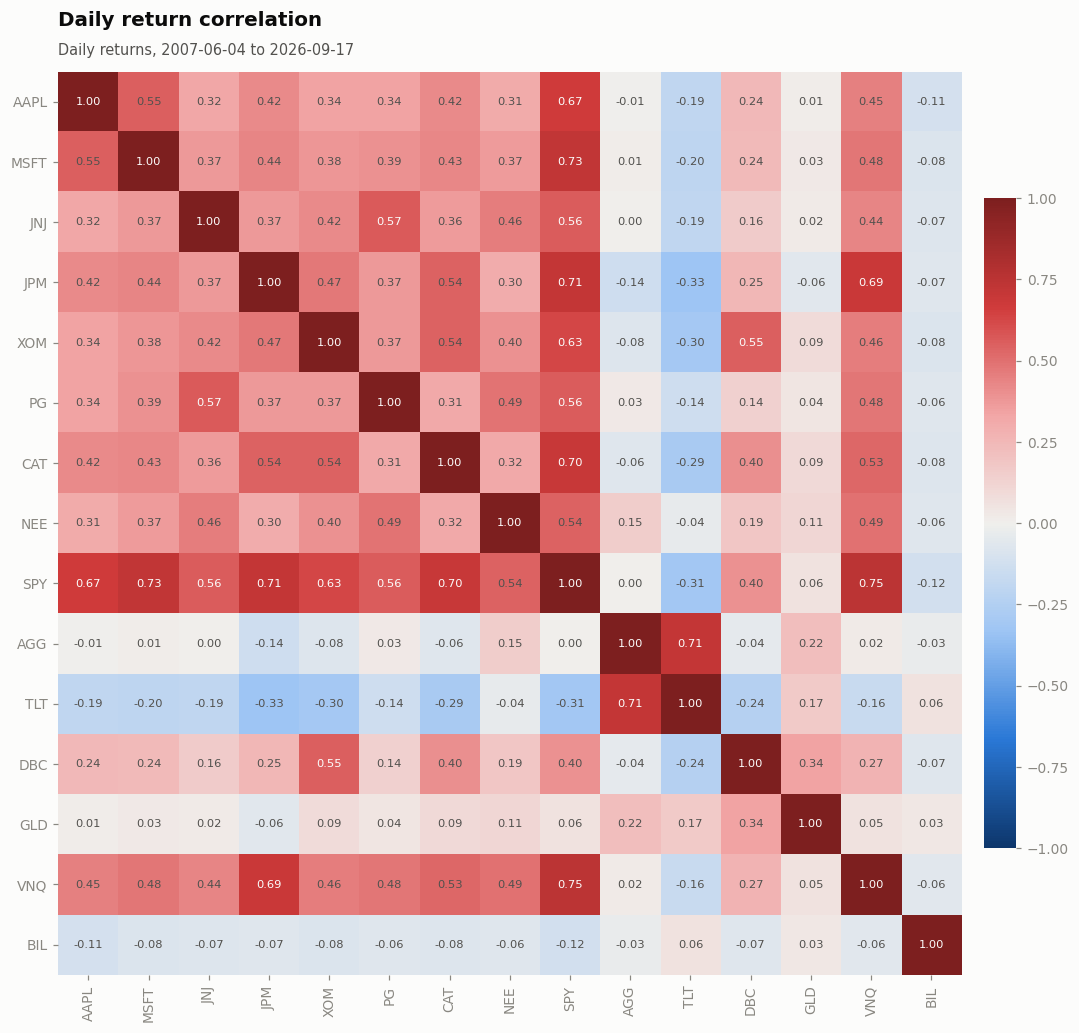

In [5]:
correlation = returns[holdings].corr()
fig = plots.plot_correlation_heatmap(
    correlation,
    subtitle=f"Daily returns, {returns.index[0].date()} to {returns.index[-1].date()}")
display(fig)

range: -0.60 to 0.41


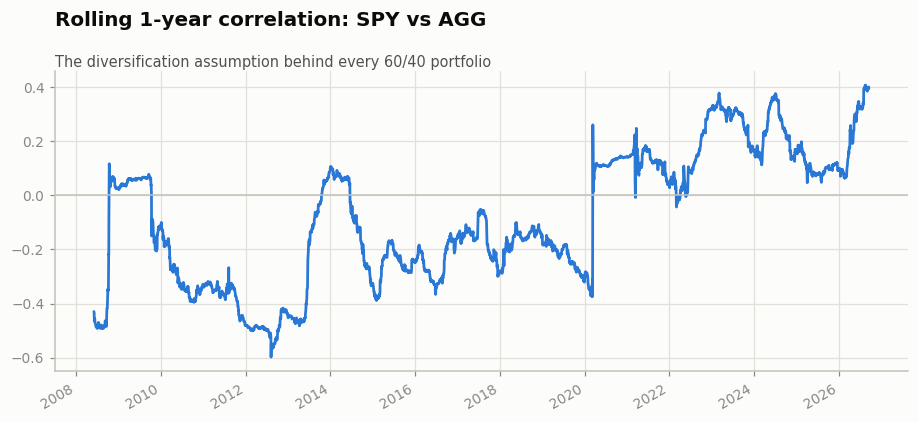

In [6]:
# How stable is the equity/bond relationship that 60/40 depends on?
rolling_corr = returns["SPY"].rolling(252).corr(returns["AGG"])
ax = rolling_corr.plot(figsize=(10, 4), color=plots.CATEGORICAL[0], linewidth=1.8)
ax.axhline(0, color=plots.BASELINE, linewidth=1)
ax.set_title("Rolling 1-year correlation: SPY vs AGG", color=plots.INK_PRIMARY, pad=30)
ax.text(0.0, 1.015, "The diversification assumption behind every 60/40 portfolio",
        transform=ax.transAxes, fontsize=9.5, color=plots.INK_SECONDARY)
ax.set_xlabel("")
print(f"range: {rolling_corr.min():.2f} to {rolling_corr.max():.2f}")

This is the single most important chart for understanding what happened to
balanced portfolios in 2022. The equity/bond correlation is not a constant — it spends
most of the sample negative (bonds hedge equities) and swings decisively positive during
the inflation shock. A 60/40 portfolio is a bet on that correlation staying negative, and
the bet does not always pay.

## 5. Covariance estimation

The minimum-variance optimiser is a function of the covariance matrix, and it
concentrates weight precisely where that matrix is least reliable: in the directions with
the smallest estimated variance. With 15 assets and a 756-day window the sample estimator
is usable but noisy, and its smallest eigenvalues are the noisiest part of it.

Ledoit-Wolf shrinkage pulls the estimate towards a scaled identity. **But it is applied
here to the *correlation* matrix, not to the covariance matrix** — a distinction that is
easy to miss and that matters a great deal in a multi-asset universe.

Shrinking the covariance matrix directly pulls every *variance* towards the average
variance. The variances in this universe span four orders of magnitude: a T-bill ETF at
0.2% annualised volatility sits alongside an industrial equity at 32%. Applied naively,
shrinkage reported the cash sleeve at roughly **4.8%** volatility — nearly twenty times its
true value — and fed that number to the optimiser and to every risk-contribution table.

Standardising first, shrinking the correlation matrix, then rescaling by the sample
standard deviations preserves each asset's own volatility exactly while still regularising
the correlation structure, which is where the estimation noise actually lives.

In [7]:
window = returns[holdings].iloc[-int(cfg.portfolios["estimation_window"]):]
sample_cov = pf.estimate_covariance(window, method="sample")
shrunk_cov = pf.estimate_covariance(window, method="ledoit_wolf")

def to_correlation(cov):
    d = np.sqrt(np.diag(cov.values))
    return cov.values / np.outer(d, d)

# 1. Variances are preserved exactly.
variances = pd.DataFrame({
    "realised_vol": window.std(ddof=1) * np.sqrt(252),
    "sample_cov_vol": np.sqrt(np.diag(sample_cov.values)) * np.sqrt(252),
    "shrunk_cov_vol": np.sqrt(np.diag(shrunk_cov.values)) * np.sqrt(252),
}, index=holdings)
display(variances.style.format("{:.2%}"))

# 2. The correlation structure is what actually gets regularised.
eig_sample = np.linalg.eigvalsh(to_correlation(sample_cov))
eig_shrunk = np.linalg.eigvalsh(to_correlation(shrunk_cov))
mask = ~np.eye(len(holdings), dtype=bool)
print(f"correlation condition number   sample {eig_sample.max()/eig_sample.min():7.2f}"
      f"   shrunk {eig_shrunk.max()/eig_shrunk.min():7.2f}")
print(f"smallest eigenvalue            sample {eig_sample.min():7.4f}"
      f"   shrunk {eig_shrunk.min():7.4f}")
print(f"mean |off-diagonal correlation| sample {np.abs(to_correlation(sample_cov)[mask]).mean():7.3f}"
      f"   shrunk {np.abs(to_correlation(shrunk_cov)[mask]).mean():7.3f}")

,realised_vol,sample_cov_vol,shrunk_cov_vol
AAPL,26.79%,26.79%,26.79%
MSFT,26.22%,26.22%,26.22%
JNJ,17.93%,17.93%,17.93%
JPM,23.01%,23.01%,23.01%
XOM,23.47%,23.47%,23.47%
PG,17.82%,17.82%,17.82%
CAT,32.46%,32.46%,32.46%
NEE,27.12%,27.12%,27.12%
SPY,15.31%,15.31%,15.31%
AGG,5.23%,5.23%,5.23%


correlation condition number   sample   62.37   shrunk   29.41
smallest eigenvalue            sample  0.0574   shrunk  0.1162
mean |off-diagonal correlation| sample   0.174   shrunk   0.163


The volatility columns match to machine precision — that is the fix working. Meanwhile
the correlation matrix's condition number roughly halves and its smallest eigenvalue
roughly doubles: the near-singular directions an unconstrained optimiser loves, and that do
not survive out of sample, have been damped without touching any asset's own risk.

## 6. Portfolio construction

### The three rules

**Equal weight (1/N).** Every holding gets the same capital. It estimates nothing, so it
cannot be wrong about anything, and it is the control against which the optimised
portfolios must justify themselves.

**Minimum variance.** Solves `min w'Σw` subject to `Σw = 1` and `0 ≤ w ≤ 0.25`. The box
constraint is doing real work: unconstrained, the solution puts almost everything in the
cash proxy, which is technically the minimum-variance answer and practically useless. The
25% cap forces the optimiser to diversify rather than simply de-risk.

**Volatility target (8%).** An equal-risk-contribution growth sleeve, scaled each quarter
so its *forecast* volatility equals 8%, with the remainder in cash. No leverage is
permitted, so in calm regimes realised volatility sits below target — a deliberate,
documented asymmetry.

**Benchmark.** Static 60% SPY / 40% AGG.

### The rebalancing discipline

Weights applied from a rebalance date onwards are estimated only from data up to and
including that date. Between rebalances they drift with realised performance. Turnover is
measured against the drifted weights and costed at 5bp round trip. The unit test
`test_no_look_ahead` corrupts the tail of the return panel and asserts that earlier
weights are unchanged.

In [8]:
results = pf.build_all_portfolios(returns, cfg)
order = ["equal_weight", "minimum_variance", "volatility_target", "benchmark"]
labels = {n: results[n].label for n in order}

for n in order:
    r = results[n]
    print(f"{r.label:<24} {r.meta['n_rebalances']:>3} rebalances   "
          f"turnover {pf.annual_turnover(r, cfg.trading_days):>6.1%}/yr")

Equal Weight              73 rebalances   turnover  16.6%/yr
Minimum Variance          73 rebalances   turnover  17.9%/yr
Volatility Target 8%      73 rebalances   turnover  29.0%/yr
60/40 Benchmark           73 rebalances   turnover   9.5%/yr


In [9]:
latest = pd.DataFrame({labels[n]: results[n].latest_weights() for n in order})
latest["sleeve"] = pd.Series(cfg.sleeve_map())
display(latest.style.format("{:.2%}", subset=[labels[n] for n in order])
        .background_gradient(cmap="Blues", subset=[labels[n] for n in order]))

,Equal Weight,Minimum Variance,Volatility Target 8%,60/40 Benchmark,sleeve
AAPL,7.52%,0.00%,4.61%,0.00%,equity
MSFT,8.49%,5.99%,7.87%,0.00%,equity
JNJ,6.62%,7.38%,8.03%,0.00%,equity
JPM,6.78%,3.86%,5.06%,0.00%,equity
XOM,7.70%,0.00%,6.33%,0.00%,equity
PG,6.36%,7.76%,7.63%,0.00%,equity
CAT,4.84%,0.00%,2.50%,0.00%,equity
NEE,5.82%,0.00%,3.51%,0.00%,equity
SPY,6.48%,0.72%,5.01%,61.04%,equity_beta
AGG,6.21%,23.18%,19.19%,38.96%,fixed_income


In [10]:
sleeve_weights = pd.DataFrame({
    labels[n]: results[n].latest_weights().groupby(pd.Series(cfg.sleeve_map())).sum()
    for n in order
})
display(sleeve_weights.style.format("{:.1%}"))

,Equal Weight,Minimum Variance,Volatility Target 8%,60/40 Benchmark
cash,6.4%,24.0%,0.0%,0.0%
commodity,14.7%,19.4%,18.1%,0.0%
equity,54.1%,25.0%,45.5%,0.0%
equity_beta,6.5%,0.7%,5.0%,61.0%
fixed_income,12.2%,31.0%,27.1%,39.0%
real_estate,6.1%,0.0%,4.2%,0.0%


The sleeve view is where the three rules become legible. Equal weight is
dominated by its equity sleeve simply because there are more equities in the universe —
1/N is not a neutral allocation, it is a bet on whatever the universe happens to contain.
Minimum variance retreats into bonds and cash. The volatility target sits between them
by construction.

## 7. Performance

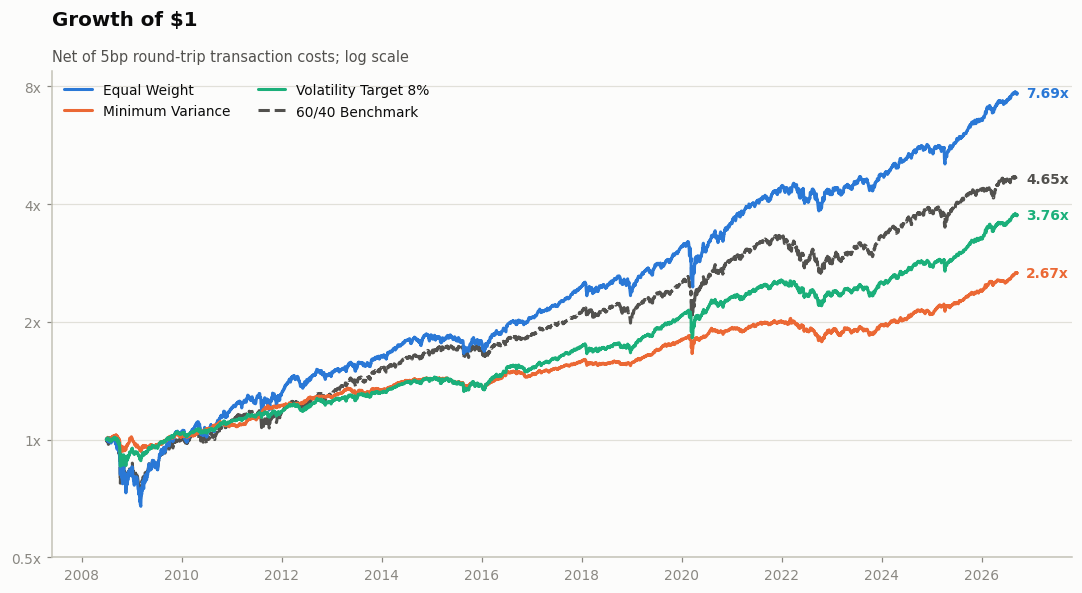

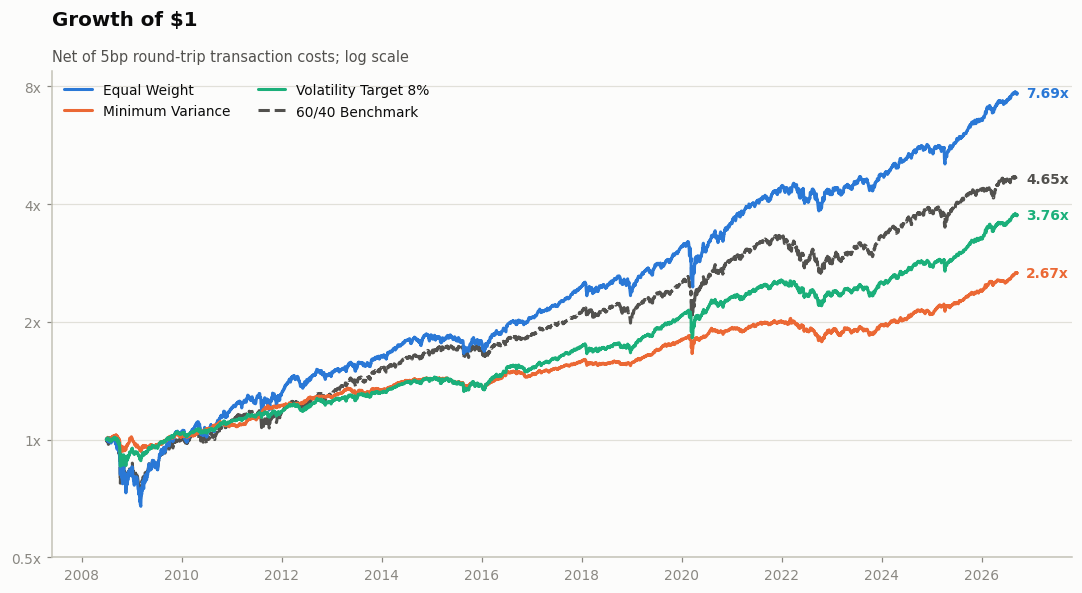

In [11]:
series = {n: results[n].returns for n in order}
display(plots.plot_cumulative_growth(series, labels))

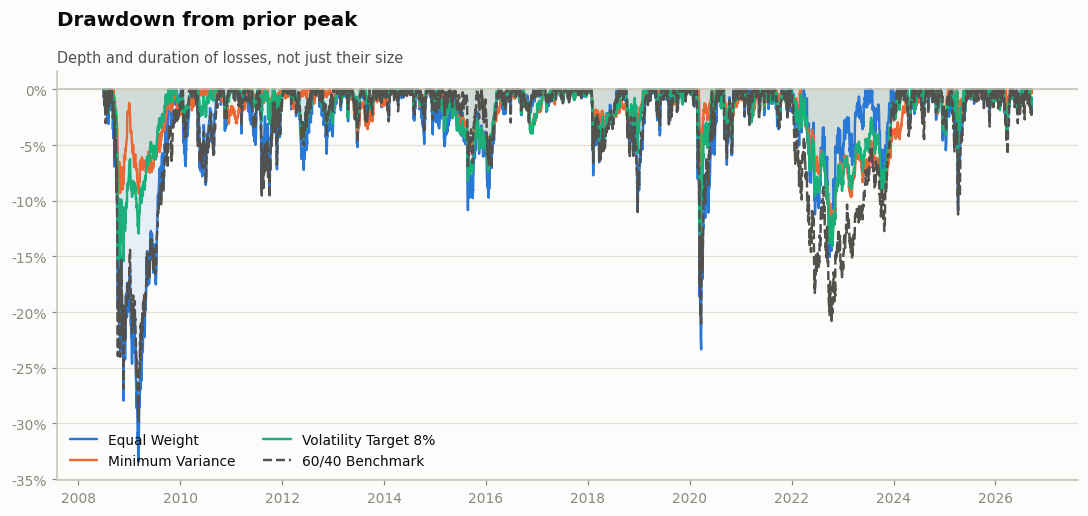

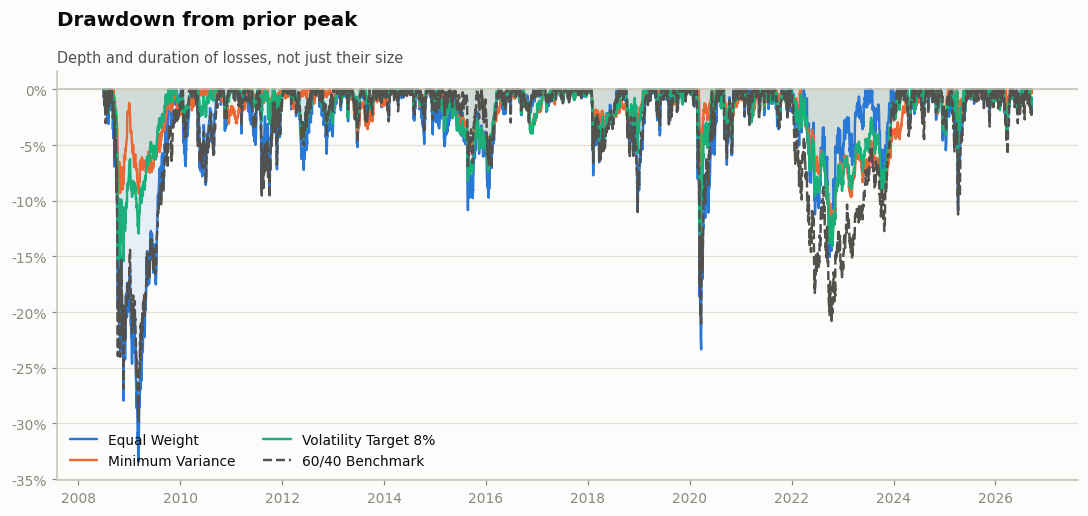

In [12]:
display(plots.plot_drawdowns(series, labels))

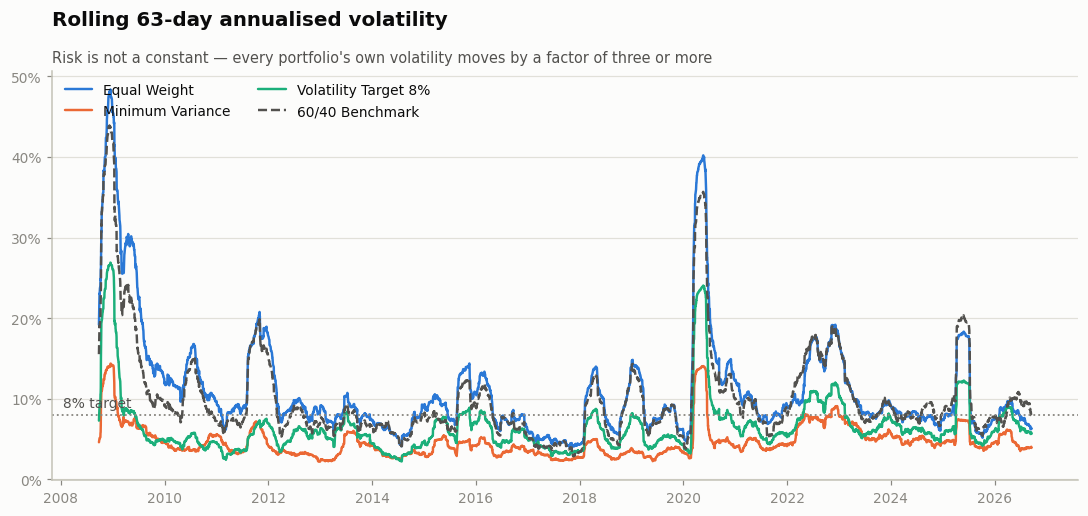

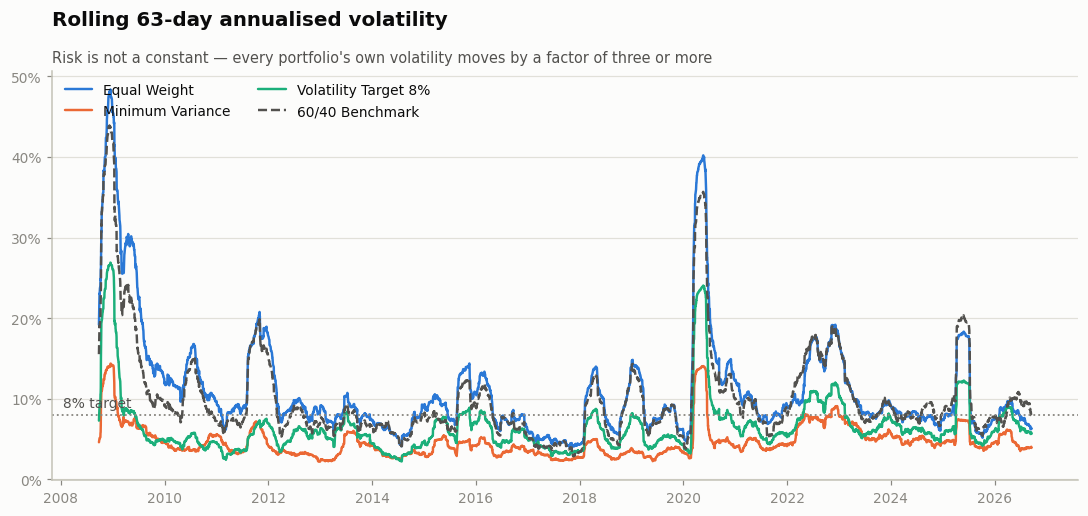

In [13]:
display(plots.plot_rolling_volatility(
    series, window=int(cfg.risk["rolling_vol_window"]),
    target=float(cfg.portfolios["volatility_target"]["target_volatility"]),
    labels=labels))

In [14]:
market = returns[cfg.market_ticker]
risk_free = dataio.risk_free_daily(returns, cfg)
summary = pd.DataFrame({
    n: mx.performance_summary(
        results[n].returns, market=market, risk_free=risk_free,
        benchmark=results["benchmark"].returns if n != "benchmark" else None,
        trading_days=cfg.trading_days)
    for n in order}).T
summary.index = [labels[n] for n in order]
display(summary[[
    "annualised_return", "annualised_volatility", "sharpe_ratio", "sortino_ratio",
    "calmar_ratio", "max_drawdown", "beta", "skewness", "excess_kurtosis",
    "upside_capture", "downside_capture"]].style.format({
        "annualised_return": "{:.2%}", "annualised_volatility": "{:.2%}",
        "max_drawdown": "{:.2%}", "sharpe_ratio": "{:.2f}", "sortino_ratio": "{:.2f}",
        "calmar_ratio": "{:.2f}", "beta": "{:.2f}", "skewness": "{:.2f}",
        "excess_kurtosis": "{:.1f}", "upside_capture": "{:.2f}",
        "downside_capture": "{:.2f}"}))

,annualised_return,annualised_volatility,sharpe_ratio,sortino_ratio,calmar_ratio,max_drawdown,beta,skewness,excess_kurtosis,upside_capture,downside_capture
Equal Weight,11.87%,13.08%,0.82,1.18,0.36,-33.44%,0.62,-0.11,11.6,1.02,0.97
Minimum Variance,5.55%,5.10%,0.83,1.18,0.43,-12.88%,0.11,-0.46,10.3,0.25,0.19
Volatility Target 8%,7.55%,7.41%,0.84,1.19,0.48,-15.74%,0.30,-0.32,19.5,0.54,0.49
60/40 Benchmark,8.82%,11.83%,0.66,0.94,0.30,-29.83%,0.59,0.08,16.9,nan,nan


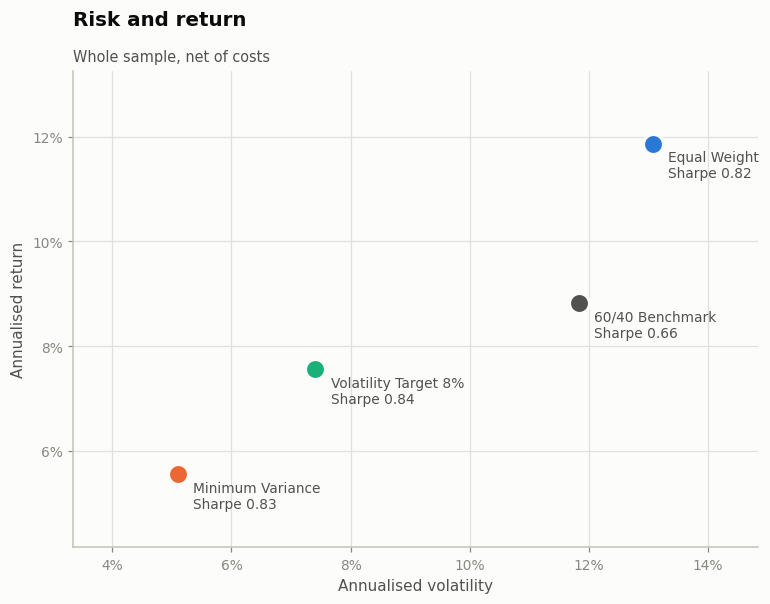

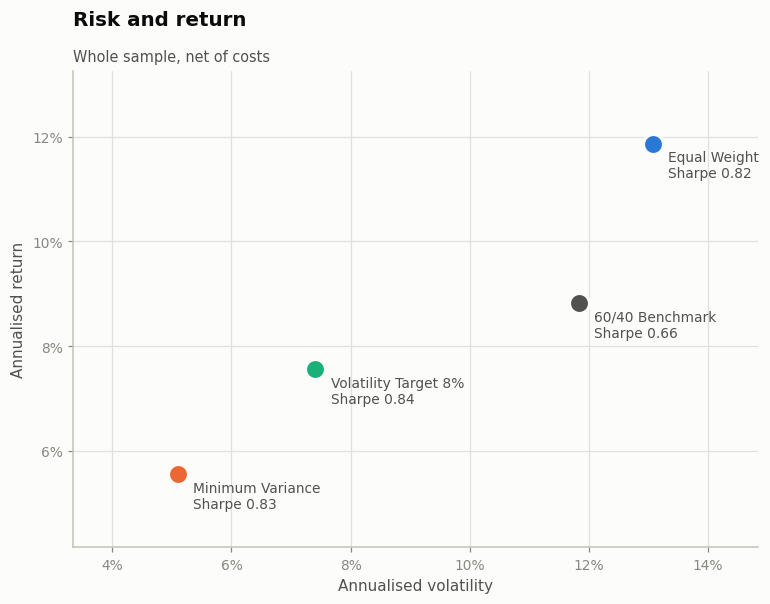

In [15]:
display(plots.plot_risk_return_scatter(summary.set_index(pd.Index(order)), labels))

### Reading the table

All three research portfolios beat the benchmark's Sharpe ratio, and they do it in
different ways — which is the finding that matters.

Equal weight earns the highest absolute return and takes the most risk to get it. Minimum
variance earns the least and takes by far the least. Their Sharpe ratios are within a few
hundredths of each other. **Construction did not create return here; it relocated risk.**
The benchmark is the outlier: it takes equal-weight-like drawdown for a materially worse
risk-adjusted outcome.

The capture ratios show the mechanism. Minimum variance participates in roughly a quarter
of the benchmark's up days and a fifth of its down days. That asymmetry — giving up less
on the downside than you surrender on the upside — is the entire economic case for a
defensive allocation, and it is what the Sharpe ratio is summarising.

## 8. Drawdown anatomy

In [16]:
anatomy = pd.DataFrame({labels[n]: mx.max_drawdown(results[n].returns)
                        for n in order}).T
display(anatomy)

,max_drawdown,peak_date,trough_date,recovery_date,drawdown_days,recovery_days
Equal Weight,-0.3344,2008-08-28 00:00:00,2009-03-09 00:00:00,2009-10-19 00:00:00,132,157
Minimum Variance,-0.1288,2022-03-08 00:00:00,2022-10-20 00:00:00,2024-05-16 00:00:00,158,395
Volatility Target 8%,-0.1574,2008-08-28 00:00:00,2008-10-10 00:00:00,2009-10-12 00:00:00,31,253
60/40 Benchmark,-0.2983,2008-08-28 00:00:00,2009-03-09 00:00:00,2010-01-14 00:00:00,132,217


**The most interesting row in this notebook.** Three of the four portfolios had
their worst drawdown in the Global Financial Crisis. The minimum-variance portfolio did
not — its worst episode was **2022**, and it took 395 trading days to recover.

That is not a defect in the portfolio; it is a statement about what it is exposed to. By
retreating into bonds and cash it largely sidestepped an equity crisis, and in doing so
concentrated itself into duration — which is exactly what the 2022 inflation shock
attacked. Every risk reduction is a risk substitution. The stress-testing notebook takes
this apart scenario by scenario.

## 9. Turnover and transaction costs

In [17]:
costs = pd.DataFrame({
    "annual_turnover": {labels[n]: pf.annual_turnover(results[n], cfg.trading_days)
                        for n in order},
    "total_cost_drag": {labels[n]: results[n].cost_drag.sum() for n in order},
    "annual_cost_drag": {labels[n]: results[n].cost_drag.sum() /
                         (len(results[n].cost_drag) / cfg.trading_days) for n in order},
    "rebalances": {labels[n]: results[n].meta["n_rebalances"] for n in order},
})
costs["gross_minus_net_ann"] = [
    mx.annualised_return(results[n].returns_gross) - mx.annualised_return(results[n].returns_net)
    for n in order]
display(costs.style.format({
    "annual_turnover": "{:.1%}", "total_cost_drag": "{:.2%}",
    "annual_cost_drag": "{:.3%}", "gross_minus_net_ann": "{:.3%}"}))

,annual_turnover,total_cost_drag,annual_cost_drag,rebalances,gross_minus_net_ann
Equal Weight,16.6%,0.30%,0.017%,73,0.019%
Minimum Variance,17.9%,0.33%,0.018%,73,0.019%
Volatility Target 8%,29.0%,0.53%,0.029%,73,0.031%
60/40 Benchmark,9.5%,0.17%,0.010%,73,0.010%


The volatility-targeted portfolio trades the most — it has to, since its whole
mechanism is adjusting exposure as forecast volatility moves. At 5bp round trip the cost
drag is a few basis points a year for every portfolio: immaterial here, but the
sensitivity is worth stating because at 25bp (a realistic figure for the individual
equities in size) the ranking of the two optimised portfolios would begin to tighten.

## 10. Allocation through time

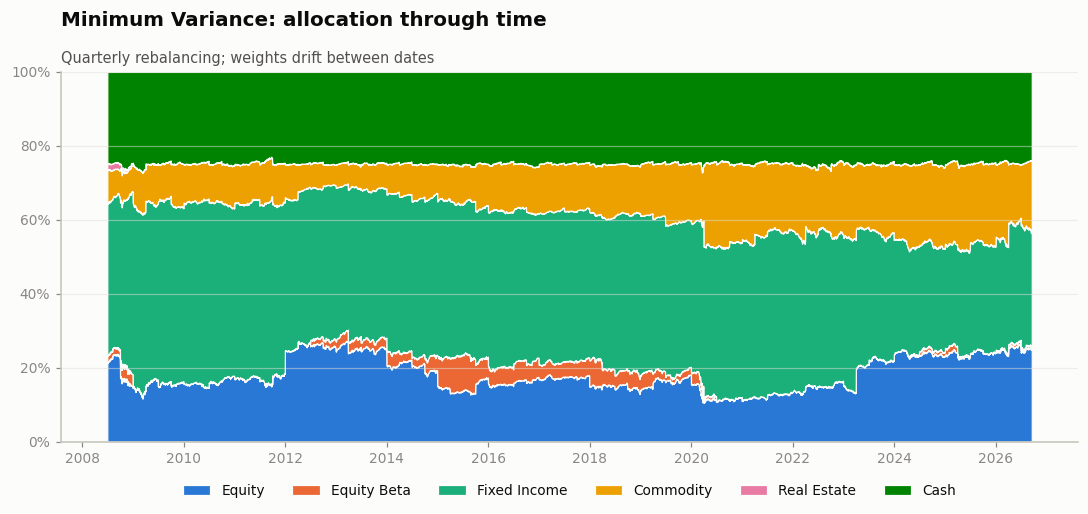

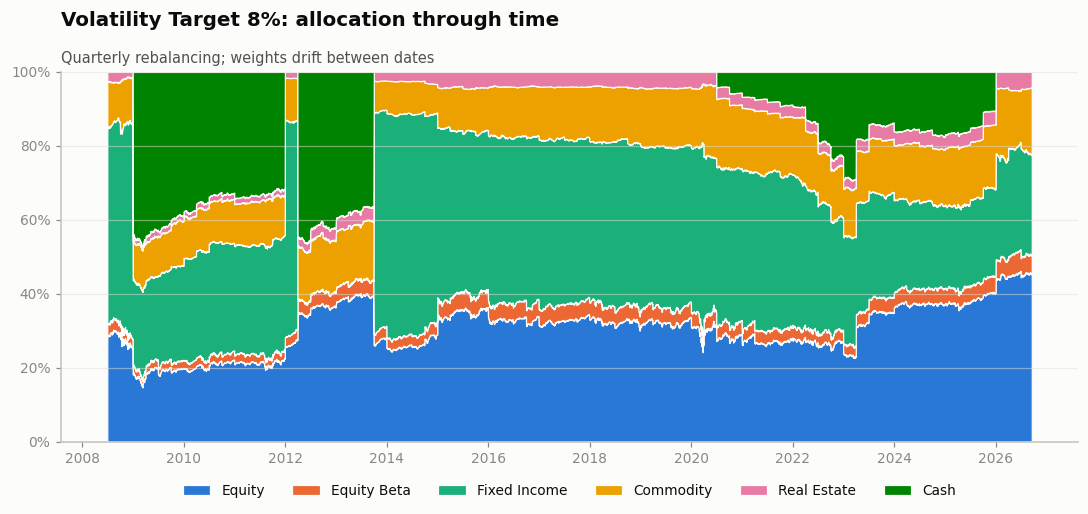

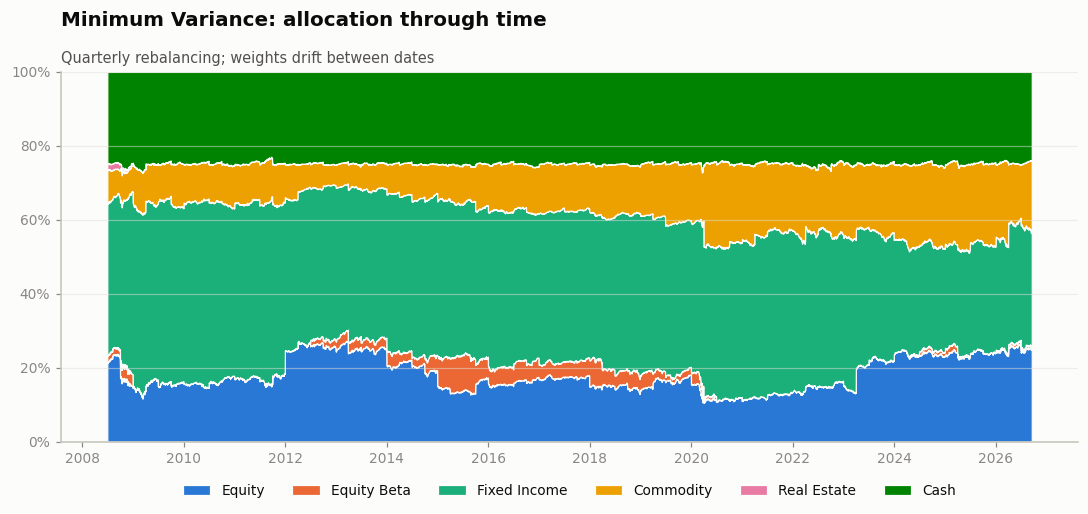

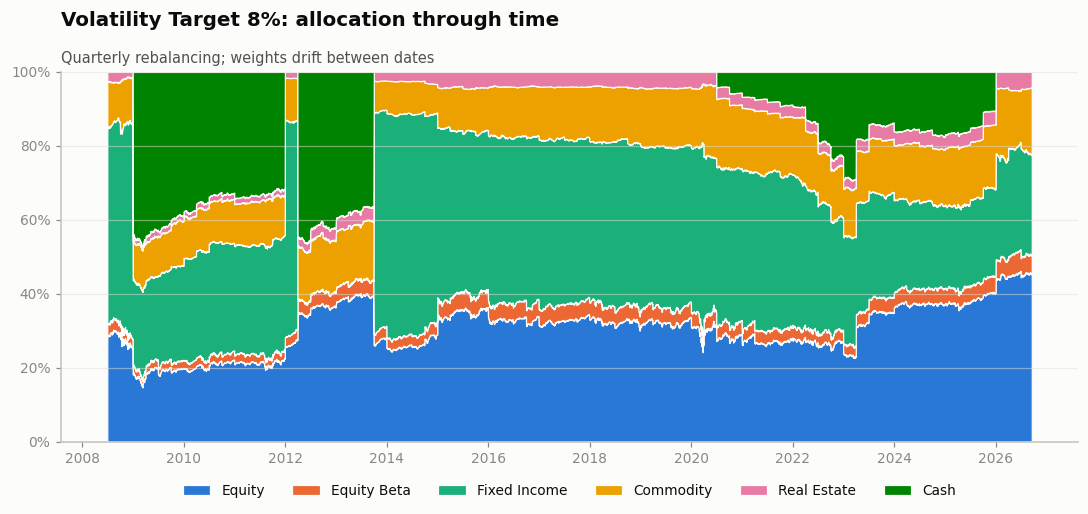

In [18]:
for n in ["minimum_variance", "volatility_target"]:
    display(plots.plot_allocation_over_time(
        results[n].weights_daily, cfg.sleeve_map(),
        title=f"{labels[n]}: allocation through time",
        subtitle="Quarterly rebalancing; weights drift between dates"))

The volatility-targeted portfolio's cash sleeve is a readable history of market
stress: it expands when forecast volatility rises and contracts when markets calm. Note
that it expands *after* volatility has risen, not before — the estimator is backward
looking, and no amount of engineering changes that. This lag is the defining limitation
of the approach and it reappears, in exactly the same form, in the VaR backtest.

## Takeaways

1. Every asset in the universe has fat tails. Normality is not a defensible default.
2. The equity/bond correlation that 60/40 depends on is not stable, and it turned
   positive in 2022.
3. Covariance shrinkage materially improves the conditioning of the optimiser's input.
4. All three construction rules produced near-identical Sharpe ratios at very different
   risk levels: construction relocated risk rather than creating return.
5. The lowest-volatility portfolio had its worst drawdown in 2022, not 2008. Reducing one
   exposure concentrates another.

**Next:** `02_risk_metrics_and_var.ipynb` measures the tail directly.